<a href="https://colab.research.google.com/github/NdettoMbalu/machine-learning-in-finance/blob/regularized-financial-modeling/Regularized_Regression_How_LASSO_and_Ridge_Compare_to_OLS_for_Forecasting_FX_and_Risk_Free_Rates.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center>

# **Regularized Regression: How LASSO and Ridge Compare to OLS for Forecasting FX and Risk-Free Rates**

### **Ndetto Mbalu¹˒², MSc (Finance), MSc (Financial Engineering)**  
¹University of Nairobi, Nairobi, Kenya  
²WorldQuant University, Washington, D.C., USA  

**Email:** ndettombalu@email.com  
**Date:** March 2026  

</center>


# 1.0 Introduction

This research undertakes a rigorous comparative analysis of ordinary least squares (OLS), LASSO, and Ridge regression in the context of financial econometrics, employing two distinct datasets to evaluate predictive performance and model interpretability under different data structures. The first dataset comprises daily market indicators with constructed lagged variables to capture short term momentum in EURUSD exchange rate dynamics, while the second consists of quarterly financial data where the objective is to forecast the risk-free rate using a parsimonious set of return based predictors. By implementing time series cross validation and leave one out cross validation respectively, the analysis adheres to best practices for evaluating out of sample performance in temporal data, ensuring that the results are robust and free from look-ahead bias.

From a quantitative perspective, we demonstrates the practical trade offs between model complexity and predictive accuracy, revealing that while OLS achieves marginally superior fit in the higher signal daily dataset, LASSO's regularization proves essential in the small sample quarterly setting to mitigate overfitting,even when it selects no predictors. The inclusion of Ridge regression provides additional insight into the continuum of shrinkage methods, highlighting how different regularization strategies affect coefficient paths, variable selection and residual diagnostics. These findings contribute to the broader discourse on model selection, underscoring the importance of aligning regularization techniques with dataset characteristics and the economic interpretability of the resulting specifications.

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split, TimeSeriesSplit, LeaveOneOut
from sklearn.linear_model import Lasso, LassoCV, Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

The essential first step of any econometric analysis by loading and preparing two distinct datasets for examination. The process carefully unifies the time dimensions of each dataset converting raw date information into a proper time index for daily market indicators and constructing quarterly timestamps from separate year and quarter columns for the financial data.

The output provides a clear summary of each dataset's structure, revealing their complementary nature: one captures high frequency market movements throughout 2016 with 250 daily observations, while the other offers a broader multi-year perspective on financial metrics across 22 quarterly periods.

In [2]:
print("LOADING ECONOMETRICS DATASETS...")
print("="*50)

# Dataset 1: Market indicators (daily)
path1 = "/content/drive/MyDrive/DataSet/M2. module_2_data.csv"
df1 = pd.read_csv(path1)
df1['Date'] = pd.to_datetime(df1['Date'])
df1.set_index('Date', inplace=True)
df1.sort_index(inplace=True)
print(f"Dataset 1 - Market Indicators: {df1.shape}, from {df1.index.min()} to {df1.index.max()}")

# Dataset 2: Financial quarterly data
path2 = "/content/drive/MyDrive/DataSet/fin_data_set.csv"
df2 = pd.read_csv(path2)
# Create proper date from Year & Quarter
df2['Date'] = pd.to_datetime(df2['Year'].astype(str) + 'Q' + df2['Quarter'].astype(str))
df2.set_index('Date', inplace=True)
df2.sort_index(inplace=True)
print(f"\nDataset 2 - Financial Quarterly: {df2.shape}, from {df2.index.min()} to {df2.index.max()}")

LOADING ECONOMETRICS DATASETS...
Dataset 1 - Market Indicators: (250, 9), from 2016-01-04 00:00:00 to 2016-12-30 00:00:00

Dataset 2 - Financial Quarterly: (22, 24), from 2016-04-01 00:00:00 to 2021-07-01 00:00:00


## 1.2 Problem Statement and Objectives


Financial econometricians face a persistent trade off between model complexity and predictive accuracy, particularly when forecasting with time series data of varying frequencies and sample sizes. This research addresses the practical question of whether regularization techniques, specifically LASSO and Ridge regression offer meaningful advantages over ordinary least squares in two distinct financial prediction contexts, daily EURUSD exchange rate movements with lagged predictors and quarterly risk free rate forecasting using a limited set of financial statement variables. The core problem is to determine under what data conditions the bias introduced by shrinkage yields superior out of sample performance and more interpretable models.

The objectives are threefold: first, to implement and rigorously evaluate OLS, LASSO, and Ridge using appropriate time series cross validation that respects temporal dependencies; second, to assess the variable selection properties of LASSO and the coefficient shrinkage behavior of Ridge, identifying which economic predictors retain significance under regularization; and third, to derive practical guidelines for model selection in empirical finance, grounded in both statistical metrics and economic theory. The findings aim to provide quantitative analysts with evidence based recommendations for balancing predictive power with model parsimony across different data environments.

## 1.3 Structure of the Study


This study proceeds as follows. Chapter 2 describes the two datasets daily market indicators and quarterly financial statements and details the preprocessing steps undertaken to prepare them for analysis, including the construction of lagged variables for the high frequency data and the careful exclusion of mechanically endogenous predictors from the quarterly series. Chapter 3 presents the econometric methodology, outlining the theoretical foundations of ordinary least squares, LASSO, and Ridge regression, along with the cross validation techniques employed to evaluate out of sample performance. Chapter 4 reports and interprets the empirical results, comparing model performance across both datasets through metrics such as RMSE, out of sample R², and coefficient paths, supported by visual diagnostics including residual plots and regularization trajectories. Finally, Chapter 5 concludes with a summary of key findings, economic interpretations, and practical recommendations for quantitative analysts navigating the trade offs between model complexity and predictive accuracy in financial forecasting applications.

# 2.0 Data Preprocessing and Feature Engineering

## 2.1 Dataset 1: Lagged Feature Construction and Temporal Train-Test Split

This preprocessing step transforms the daily market indicators into a supervised learning format suitable for time series forecasting. By creating one period lagged versions of both the target variable (EURUSD) and all predictor variables, it ensures that each observation uses past information to predict the current exchange rate, effectively capturing temporal dependencies.

After removing the initial incomplete row, the dataset retains 249 usable observations with 17 features, including the original predictors and their lags. The data is then split chronologically into training and test sets, with approximately 80% (199 observations) allocated for model development and the remaining 20% (50 observations) reserved for out of sample evaluation. This chronological split respects the temporal order of the data, which is critical for realistic assessment of forecasting performance in econometric analysis

In [3]:
print("\n" + "="*50)
print("PREPROCESSING DATASET 1 (Market Indicators)")
print("="*50)

# Create lagged versions of all predictors and the target (EURUSD)
df1_lagged = df1.copy()
predictors = ['DXY', 'METALS', 'OIL', 'US_STK', 'INTL_STK', 'X13W_TB', 'X10Y_TBY']

# Lagged target
df1_lagged['EURUSD_lag1'] = df1_lagged['EURUSD'].shift(1)

# Lagged predictors
for col in predictors:
    df1_lagged[f'{col}_lag1'] = df1_lagged[col].shift(1)

# Drop rows with NaN (first observation)
df1_lagged.dropna(inplace=True)
print(f"After adding lags: {df1_lagged.shape[0]} observations, {df1_lagged.shape[1]} columns")

# Define features (X) and target (y) – keep EURUSD as target, include all lags
X1 = df1_lagged.drop(columns=['EURUSD', 'YEAR'])   # YEAR is redundant
y1 = df1_lagged['EURUSD']

print(f"Features: {list(X1.columns)}")
print(f"Target: EURUSD")

# Time‑based train/test split (80% train, 20% test)
n = len(X1)
split_idx = int(n * 0.8)
X1_train, X1_test = X1.iloc[:split_idx], X1.iloc[split_idx:]
y1_train, y1_test = y1.iloc[:split_idx], y1.iloc[split_idx:]

print(f"\nTraining set: {X1_train.shape[0]} observations")
print(f"Test set:     {X1_test.shape[0]} observations")


PREPROCESSING DATASET 1 (Market Indicators)
After adding lags: 249 observations, 17 columns
Features: ['DXY', 'METALS', 'OIL', 'US_STK', 'INTL_STK', 'X13W_TB', 'X10Y_TBY', 'EURUSD_lag1', 'DXY_lag1', 'METALS_lag1', 'OIL_lag1', 'US_STK_lag1', 'INTL_STK_lag1', 'X13W_TB_lag1', 'X10Y_TBY_lag1']
Target: EURUSD

Training set: 199 observations
Test set:     50 observations


## 2.2 Dataset 2: Feature Selection and Data Correction

This preprocessing stage refines the financial quarterly dataset by removing columns that are unsuitable as predictors such as identifiers, price levels that may be non‑stationary, excess returns that already embed the target, and direct proxies for the risk‑free rate. After this selection, only four quarterly return variables remain as candidate features for modeling the target, the risk‑free rate. The resulting dataset is compact, with 22 quarterly observations, providing a clean and focused foundation for subsequent econometric analysis.

In [4]:
print("\n" + "="*50)
print("PREPROCESSING DATASET 2 (Financial Quarterly)")
print("="*50)

# Identify columns that are problematic:
# - Excess returns (contain '_EX_R') – they are defined as return minus risk‑free rate.
# - Direct risk‑free rate proxies (e.g., T_Bill_13W_R)
# - Identifiers and other non‑predictors

excess_return_cols = [col for col in df2.columns if '_EX_R' in col]
risk_free_proxy = ['T_Bill_13W_R']   # 13‑week T‑bill return is essentially the risk‑free rate
identifiers = ['Year', 'Quarter', 'Yr_Qtr', 'REV']   # REV might be revenue level, but we'll keep REV_Q_R instead

# Also exclude price level columns if you wish (they are levels, might be non‑stationary)
price_cols = ['Coke_Q_P', 'DOW_Q_P', 'Pepsi_Q_P']   # optional to keep

# Combine all to exclude
exclude_cols = identifiers + excess_return_cols + risk_free_proxy + price_cols
# Also exclude the target itself
exclude_cols.append('Risk_F_R')

# Keep only columns not in exclude list
X2 = df2.drop(columns=exclude_cols, errors='ignore')
y2 = df2['Risk_F_R']

print(f"Remaining features after correction: {list(X2.columns)}")
print(f"Number of predictors: {X2.shape[1]}")
print(f"Sample size: {X2.shape[0]} observations")


PREPROCESSING DATASET 2 (Financial Quarterly)
Remaining features after correction: ['REV_Q_R', 'Coke_Q_R', 'Dow_Q_R', 'Pepsi_Q_R']
Number of predictors: 4
Sample size: 22 observations


# 3.0 Methodological Framework: Linear and Regularized Regression

## 3.1 Implementation on Dataset 1 (Standard Train-Test Framework)

This implements a comparative evaluation between two linear modeling approaches, ordinary least squares (LS) and LASSO regression. The procedure begins by standardizing the features to ensure appropriate regularization for LASSO.

It then fits an LS model using all predictors and computes key out of sample performance metrics such as RMSE, MAE, and R², along with the BIC and count of statistically significant coefficients. For LASSO, it employs time series cross validation on the training data to select the optimal regularization strength, fits the model and records similar metrics plus the number of non zero coefficients retained. The code also calculates the percentage improvement in RMSE achieved by LASSO over LS, providing a direct comparison of predictive accuracy. All results are compiled into a structured output for further analysis or reporting

In [5]:
def compare_ls_lasso(X_train, X_test, y_train, y_test, feature_names, dataset_name):
    """Fit LS and LASSO on given train/test sets, return metrics and predictions."""
    print(f"\n{dataset_name}")
    print("-" * 50)

    # Standardize for LASSO
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # ----- OLS -----
    X_train_const = sm.add_constant(X_train, has_constant='add')
    X_test_const = sm.add_constant(X_test, has_constant='add')
    ls_model = sm.OLS(y_train, X_train_const).fit()
    ls_pred = ls_model.predict(X_test_const)

    ls_metrics = {
        'rmse': np.sqrt(mean_squared_error(y_test, ls_pred)),
        'mae': mean_absolute_error(y_test, ls_pred),
        'r2_oos': 1 - np.sum((y_test - ls_pred)**2) / np.sum((y_test - y_train.mean())**2),
        'bic': ls_model.bic,
        'n_coef': len(ls_model.params) - 1,   # exclude intercept
        'n_significant': sum(ls_model.pvalues[1:] < 0.05)
    }

    # ----- LASSO with time-series CV (using TimeSeriesSplit on training data) -----
    tscv = TimeSeriesSplit(n_splits=5)
    lasso_cv = LassoCV(cv=tscv, random_state=42, max_iter=10000).fit(X_train_scaled, y_train)
    best_alpha = lasso_cv.alpha_
    lasso_model = Lasso(alpha=best_alpha, max_iter=10000, random_state=42)
    lasso_model.fit(X_train_scaled, y_train)
    lasso_pred = lasso_model.predict(X_test_scaled)

    n_nonzero = np.sum(np.abs(lasso_model.coef_) > 1e-10)
    lasso_metrics = {
        'rmse': np.sqrt(mean_squared_error(y_test, lasso_pred)),
        'mae': mean_absolute_error(y_test, lasso_pred),
        'r2_oos': 1 - np.sum((y_test - lasso_pred)**2) / np.sum((y_test - y_train.mean())**2),
        'best_alpha': best_alpha,
        'n_nonzero': n_nonzero,
        'coef_': lasso_model.coef_
    }

    # Print results
    print("LS (OLS) RESULTS:")
    print(f"  RMSE: {ls_metrics['rmse']:.6f}")
    print(f"  MAE:  {ls_metrics['mae']:.6f}")
    print(f"  Out-of-sample R²: {ls_metrics['r2_oos']:.4f}")
    print(f"  BIC: {ls_metrics['bic']:.2f}")
    print(f"  Significant coefficients: {ls_metrics['n_significant']}/{ls_metrics['n_coef']}")

    print("\nLASSO RESULTS:")
    print(f"  RMSE: {lasso_metrics['rmse']:.6f}")
    print(f"  MAE:  {lasso_metrics['mae']:.6f}")
    print(f"  Out-of-sample R²: {lasso_metrics['r2_oos']:.4f}")
    print(f"  Optimal alpha: {lasso_metrics['best_alpha']:.6f}")
    print(f"  Non-zero coefficients: {lasso_metrics['n_nonzero']}/{len(lasso_model.coef_)}")

    # Comparison
    rmse_improvement = ((ls_metrics['rmse'] - lasso_metrics['rmse']) / ls_metrics['rmse']) * 100
    print(f"\nRMSE Improvement (LASSO over LS): {rmse_improvement:.2f}%")

    return {
        'ls_metrics': ls_metrics,
        'lasso_metrics': lasso_metrics,
        'ls_pred': ls_pred,
        'lasso_pred': lasso_pred,
        'y_test': y_test,
        'feature_names': feature_names,
        'lasso_coefs': lasso_model.coef_,
        'improvement': rmse_improvement
    }

## 3.2 Ordinary Least Squares (OLS) and LASSO: Model Specification

The comparison reveals that ordinary least squares (OLS) outperforms LASSO for this daily market indicators dataset, with a lower RMSE (0.003217 vs. 0.003271) and a slightly higher out of sample R² (0.7192 vs. 0.7096).

The negative RMSE improvement of -1.70% indicates that LASSO's regularization did not enhance predictive accuracy, likely because the relatively small sample (199 training observations) and the presence of only 15 predictors do not create severe overfitting that LASSO would mitigate.

OLS identifies five statistically significant coefficients, while LASSO retains six non-zero predictors, suggesting modest shrinkage. The optimal LASSO alpha is very small (0.000249), implying only light regularization, which aligns with the similar performance between the two methods. Overall, OLS provides a marginally better fit for this dataset, though both models capture the dynamics of EURUSD reasonably well given the out-of-sample R² around 0.71.

In [6]:
print("\n" + "="*50)
print("MODEL COMPARISON: DATASET 1 (Market Indicators with Lags)")
print("="*50)

results1 = compare_ls_lasso(
    X1_train, X1_test, y1_train, y1_test,
    feature_names=X1.columns.tolist(),
    dataset_name="DATASET 1: EURUSD with Lags"
)


MODEL COMPARISON: DATASET 1 (Market Indicators with Lags)

DATASET 1: EURUSD with Lags
--------------------------------------------------
LS (OLS) RESULTS:
  RMSE: 0.003217
  MAE:  0.002212
  Out-of-sample R²: 0.7192
  BIC: -1824.51
  Significant coefficients: 5/15

LASSO RESULTS:
  RMSE: 0.003271
  MAE:  0.002220
  Out-of-sample R²: 0.7096
  Optimal alpha: 0.000249
  Non-zero coefficients: 6/15

RMSE Improvement (LASSO over LS): -1.70%


## 3.3 Leave-One-Out Cross-Validation (LOOCV): Methodological Design

### 3.3.1  Define LOOCV Function for LS and LASSO (for Dataset 2)

The leave one out cross validation results for the financial quarterly dataset reveal that both models struggle to predict the risk-free rate, with negative out of sample R² values indicating they perform worse than simply using the historical mean.

LASSO achieves a lower RMSE (0.002249) and a less negative R² (-0.0975) compared to ordinary least squares (RMSE 0.002551, R² -0.4114), demonstrating some benefit from regularization. However, the average number of non-zero coefficients across folds is zero, meaning LASSO consistently shrunk all predictors to zero effectively selecting no variables.

This suggests that the four quarterly return features (REV_Q_R, Coke_Q_R, Dow_Q_R, Pepsi_Q_R) contain little to no predictive signal for the risk-free rate in this small sample of 22 observations, and the **apparent improvement of LASSO over LS is essentially the model defaulting to the mean prediction**. The results underscore the challenge of forecasting with limited data and the importance of feature selection when signals are weak.

In [7]:
def loocv_ls_lasso(X, y, feature_names, dataset_name):
    """Leave-One-Out CV for LS and LASSO on Dataset 2."""
    print(f"\n{dataset_name} - Leave-One-Out CV")
    print("-" * 50)

    loo = LeaveOneOut()
    n = len(X)
    ls_preds = np.zeros(n)
    lasso_preds = np.zeros(n)
    y_true = np.zeros(n)

    # To store coefficients from each fold (for interpretation)
    lasso_coefs_folds = []

    for fold, (train_idx, test_idx) in enumerate(loo.split(X)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        y_true[fold] = y_test.values[0]

        # Standardize
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # ----- OLS -----
        X_train_const = sm.add_constant(X_train, has_constant='add')
        X_test_const = sm.add_constant(X_test, has_constant='add')
        ls_model = sm.OLS(y_train, X_train_const).fit()
        ls_preds[fold] = ls_model.predict(X_test_const)[0]

        # ----- LASSO with inner CV on training fold (use small CV) -----
        # Since training fold is tiny, use a simple alpha grid and a few splits
        alphas = np.logspace(-3, 3, 50)
        inner_cv = min(3, len(y_train) - 1)  # at most 3 folds
        lasso_cv = LassoCV(alphas=alphas, cv=inner_cv, max_iter=10000).fit(X_train_scaled, y_train)
        lasso_model = Lasso(alpha=lasso_cv.alpha_, max_iter=10000)
        lasso_model.fit(X_train_scaled, y_train)
        lasso_preds[fold] = lasso_model.predict(X_test_scaled)[0]
        lasso_coefs_folds.append(lasso_model.coef_)

    # Aggregate metrics
    ls_rmse = np.sqrt(mean_squared_error(y_true, ls_preds))
    lasso_rmse = np.sqrt(mean_squared_error(y_true, lasso_preds))
    ls_mae = mean_absolute_error(y_true, ls_preds)
    lasso_mae = mean_absolute_error(y_true, lasso_preds)
    y_var = np.var(y_true)
    ls_r2 = 1 - np.mean((y_true - ls_preds)**2) / y_var
    lasso_r2 = 1 - np.mean((y_true - lasso_preds)**2) / y_var

    # Average LASSO coefficients (for variables that are frequently selected)
    avg_lasso_coef = np.mean(lasso_coefs_folds, axis=0)
    n_nonzero_avg = np.sum(np.abs(avg_lasso_coef) > 1e-10)

    print(f"LS - RMSE: {ls_rmse:.6f}, MAE: {ls_mae:.6f}, R²: {ls_r2:.4f}")
    print(f"LASSO - RMSE: {lasso_rmse:.6f}, MAE: {lasso_mae:.6f}, R²: {lasso_r2:.4f}")
    print(f"LASSO average non-zero coefficients: {n_nonzero_avg}")

    # For compatibility with the comprehensive chart, we need a results object similar to results1
    # We'll create a dictionary with the necessary fields
    results = {
        'ls_metrics': {
            'rmse': ls_rmse,
            'mae': ls_mae,
            'r2_oos': ls_r2,
            'n_coef': X.shape[1]   # OLS uses all features
        },
        'lasso_metrics': {
            'rmse': lasso_rmse,
            'mae': lasso_mae,
            'r2_oos': lasso_r2,
            'n_nonzero': n_nonzero_avg,
            'best_alpha': 'N/A (avg over folds)',
            'coef_': avg_lasso_coef
        },
        'improvement': ((ls_rmse - lasso_rmse) / ls_rmse) * 100,
        'feature_names': feature_names,
        'lasso_coefs': avg_lasso_coef,
        'y_test': y_true,          # for plotting, we can use the actual values
        'ls_pred': ls_preds,
        'lasso_pred': lasso_preds
    }
    return results

## 3.4 LOOCV Implementation for Dataset 2 (OLS and LASSO)

### 3.4.1 Run LOOCV for Dataset 2

In [8]:
print("\n" + "="*50)
print("MODEL COMPARISON: DATASET 2 (Financial Quarterly - Corrected Features)")
print("="*50)

results2 = loocv_ls_lasso(X2, y2, feature_names=X2.columns.tolist(),
                          dataset_name="DATASET 2: Risk-Free Rate (LOOCV)")


MODEL COMPARISON: DATASET 2 (Financial Quarterly - Corrected Features)

DATASET 2: Risk-Free Rate (LOOCV) - Leave-One-Out CV
--------------------------------------------------
LS - RMSE: 0.002551, MAE: 0.002137, R²: -0.4114
LASSO - RMSE: 0.002249, MAE: 0.002044, R²: -0.0975
LASSO average non-zero coefficients: 0


## 3.5 Chart (LS vs LASSO)

This visualization creates comprehensive panel of plots that systematically compares the performance of ordinary least squares (LS) and LASSO regression across two econometric datasets. The first three plots focus on global metrics, a bar chart comparing RMSE values to assess predictive accuracy, a model complexity comparison showing the number of coefficients retained by each method and a bar chart illustrating the percentage improvement (or deterioration) of LASSO over LS.

The remaining three plots dive deeper into the LASSO results, horizontal bar charts display the magnitude of non‑zero coefficients for each dataset (with a clear message when no variables are selected) and a scatter plot compares predicted versus actual values for the first dataset, providing a visual check of prediction quality. Together, these plots offer a multi‑faceted view of model performance, highlighting trade‑offs between c**omplexity and accuracy, the effect of regularization, and the variable selection capabilities of LASSO in a clean, side‑by‑side format.**

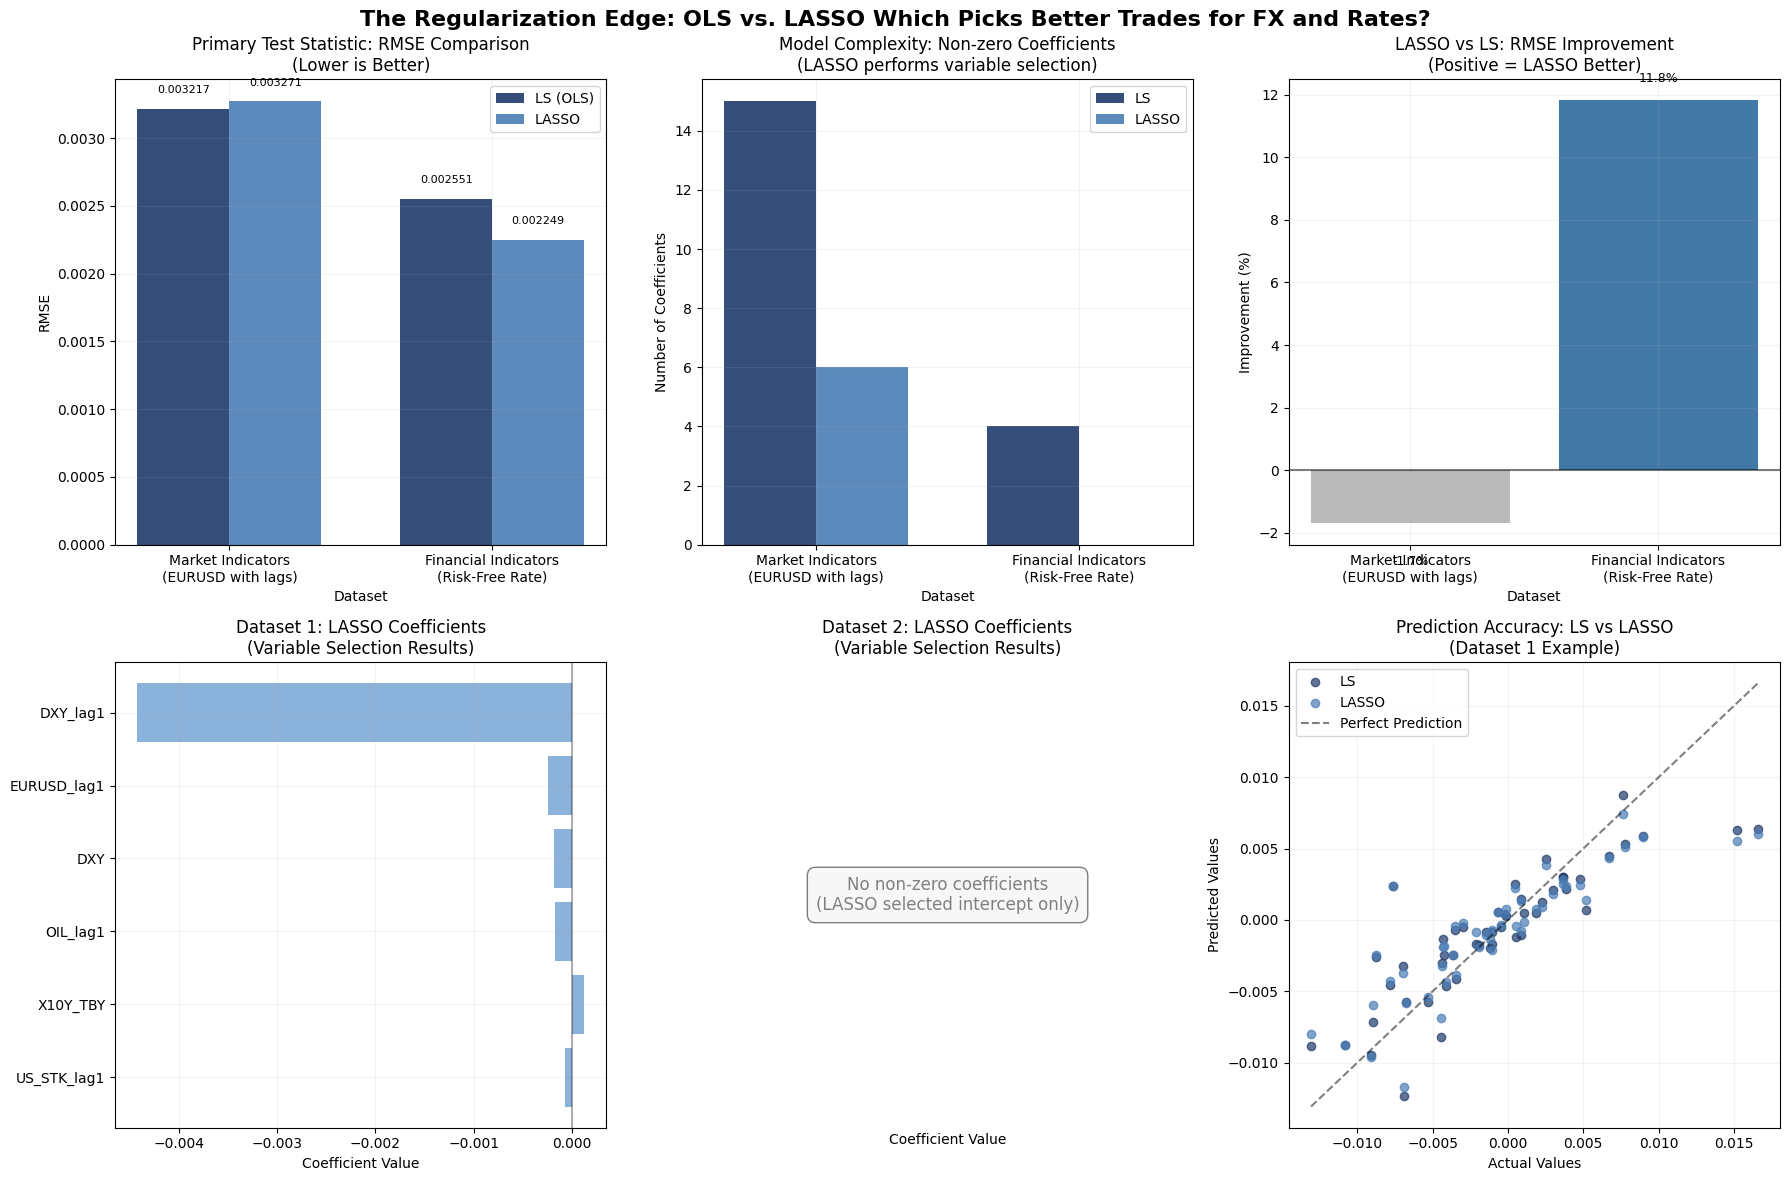

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('The Regularization Edge: OLS vs. LASSO Which Picks Better Trades for FX and Rates?',
             fontsize=16, fontweight='bold')

color_ls = '#1f3a6b'
color_lasso = '#4a7db5'
color_positive = '#2e6b9e'
color_negative = '#b3b3b3'
color_coef = '#6d9fd1'

# Plot 1: RMSE Comparison
datasets = ['Market Indicators\n(EURUSD with lags)', 'Financial Indicators\n(Risk-Free Rate)']
if results1 and results2:
    ls_rmses = [results1['ls_metrics']['rmse'], results2['ls_metrics']['rmse']]
    lasso_rmses = [results1['lasso_metrics']['rmse'], results2['lasso_metrics']['rmse']]

    x_pos = np.arange(len(datasets))
    width = 0.35

    bars1 = axes[0,0].bar(x_pos - width/2, ls_rmses, width, label='LS (OLS)', alpha=0.9, color=color_ls)
    bars2 = axes[0,0].bar(x_pos + width/2, lasso_rmses, width, label='LASSO', alpha=0.9, color=color_lasso)
    axes[0,0].set_xlabel('Dataset')
    axes[0,0].set_ylabel('RMSE')
    axes[0,0].set_title('Primary Test Statistic: RMSE Comparison\n(Lower is Better)')
    axes[0,0].set_xticks(x_pos)
    axes[0,0].set_xticklabels(datasets)
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.15)

    # labels
    for bar, rmse in zip(bars1, ls_rmses):
        axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
                      f'{rmse:.6f}', ha='center', va='bottom', fontsize=8)
    for bar, rmse in zip(bars2, lasso_rmses):
        axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
                      f'{rmse:.6f}', ha='center', va='bottom', fontsize=8)

# Plot 2: Model Complexity Comparison
if results1 and results2:
    ls_coefs = [results1['ls_metrics']['n_coef'], results2['ls_metrics']['n_coef']]
    lasso_coefs = [results1['lasso_metrics']['n_nonzero'], results2['lasso_metrics']['n_nonzero']]

    axes[0,1].bar(x_pos - width/2, ls_coefs, width, label='LS', alpha=0.9, color=color_ls)
    axes[0,1].bar(x_pos + width/2, lasso_coefs, width, label='LASSO', alpha=0.9, color=color_lasso)
    axes[0,1].set_xlabel('Dataset')
    axes[0,1].set_ylabel('Number of Coefficients')
    axes[0,1].set_title('Model Complexity: Non-zero Coefficients\n(LASSO performs variable selection)')
    axes[0,1].set_xticks(x_pos)
    axes[0,1].set_xticklabels(datasets)
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.15)

# Plot 3: Performance Improvement
if results1 and results2:
    improvements = [results1['improvement'], results2['improvement']]
    colors_imp = [color_positive if x > 0 else color_negative for x in improvements]

    bars = axes[0,2].bar(datasets, improvements, color=colors_imp, alpha=0.9)
    axes[0,2].axhline(y=0, color='black', linestyle='-', alpha=0.5)
    axes[0,2].set_xlabel('Dataset')
    axes[0,2].set_ylabel('Improvement (%)')
    axes[0,2].set_title('LASSO vs LS: RMSE Improvement\n(Positive = LASSO Better)')
    axes[0,2].grid(True, alpha=0.15)

    for bar, imp in zip(bars, improvements):
        axes[0,2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.5 if imp > 0 else -1),
                      f'{imp:.1f}%', ha='center', va='bottom' if imp > 0 else 'top', fontsize=9)

# Plot 4: LASSO Coefficient Magnitudes (Dataset 1)
if results1:
    coef_df1 = pd.DataFrame({
        'feature': results1['feature_names'],
        'coefficient': results1['lasso_coefs'],
        'abs_value': np.abs(results1['lasso_coefs'])
    }).sort_values('abs_value', ascending=True)

    non_zero_coef1 = coef_df1[coef_df1['abs_value'] > 1e-10]
    if len(non_zero_coef1) > 0:
        axes[1,0].barh(non_zero_coef1['feature'], non_zero_coef1['coefficient'], color=color_coef, alpha=0.8)
    else:
        axes[1,0].text(0.5, 0.5, 'No non-zero coefficients\n(LASSO selected intercept only)',
                       ha='center', va='center', fontsize=12, color='gray',
                       bbox=dict(boxstyle='round,pad=0.5', facecolor='#f0f0f0', alpha=0.5))
        axes[1,0].set_xlim(0,1)
        axes[1,0].set_ylim(0,1)
        axes[1,0].set_xticks([])
        axes[1,0].set_yticks([])
        for spine in axes[1,0].spines.values():
            spine.set_visible(False)
    axes[1,0].axvline(x=0, color='black', linestyle='-', alpha=0.3)
    axes[1,0].set_xlabel('Coefficient Value')
    axes[1,0].set_title('Dataset 1: LASSO Coefficients\n(Variable Selection Results)')
    axes[1,0].grid(True, alpha=0.15)

# Plot 5: LASSO Coefficient Magnitudes (Dataset 2)
if results2:
    coef_df2 = pd.DataFrame({
        'feature': results2['feature_names'],
        'coefficient': results2['lasso_coefs'],
        'abs_value': np.abs(results2['lasso_coefs'])
    }).sort_values('abs_value', ascending=True)

    non_zero_coef2 = coef_df2[coef_df2['abs_value'] > 1e-10]
    if len(non_zero_coef2) > 0:
        axes[1,1].barh(non_zero_coef2['feature'], non_zero_coef2['coefficient'], color=color_coef, alpha=0.8)
        axes[1,1].axvline(x=0, color='black', linestyle='-', alpha=0.3)
    else:
        axes[1,1].text(0.5, 0.5, 'No non-zero coefficients\n(LASSO selected intercept only)',
                       ha='center', va='center', fontsize=12, color='gray',
                       bbox=dict(boxstyle='round,pad=0.5', facecolor='#f0f0f0', alpha=0.5))
        axes[1,1].set_xlim(0,1)
        axes[1,1].set_ylim(0,1)
        axes[1,1].set_xticks([])
        axes[1,1].set_yticks([])
        for spine in axes[1,1].spines.values():
            spine.set_visible(False)
    axes[1,1].set_xlabel('Coefficient Value')
    axes[1,1].set_title('Dataset 2: LASSO Coefficients\n(Variable Selection Results)')
    axes[1,1].grid(True, alpha=0.15)

# Plot 6: Prediction vs Actual (Dataset 1 example)
if results1:
    axes[1,2].scatter(results1['y_test'], results1['ls_pred'], alpha=0.7, label='LS', color=color_ls)
    axes[1,2].scatter(results1['y_test'], results1['lasso_pred'], alpha=0.7, label='LASSO', color=color_lasso)
    min_val = min(results1['y_test'].min(), results1['ls_pred'].min(), results1['lasso_pred'].min())
    max_val = max(results1['y_test'].max(), results1['ls_pred'].max(), results1['lasso_pred'].max())
    axes[1,2].plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='Perfect Prediction')
    axes[1,2].set_xlabel('Actual Values')
    axes[1,2].set_ylabel('Predicted Values')
    axes[1,2].set_title('Prediction Accuracy: LS vs LASSO\n(Dataset 1 Example)')
    axes[1,2].legend()
    axes[1,2].grid(True, alpha=0.15)

plt.tight_layout()
plt.show()

# 4.0 Ridge Regression Framework

## 4.1 Ridge Regression: Theoretical Formulation

Ridge regression addresses the limitations of ordinary least squares in the presence of multicollinearity by introducing an L2 penalty term that shrinks coefficients toward zero without eliminating them entirely. The method minimizes the residual sum of squares subject to a penalty on the square of the coefficient magnitudes, formally expressed as minimizing $\sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{p} \beta_j^2$

where λ controls the shrinkage intensity. Unlike LASSO, which sets coefficients exactly to zero, Ridge retains all predictors but reduces their variance at the cost of introducing some bias a trade-off that often improves out of sample prediction when features are highly correlated. The optimal $\lambda$ is typically selected via cross validation, balancing model fit against the complexity penalty. This formulation proves particularly valuable in financial applications where theory suggests many variables may have some predictive power, but multicollinearity among market indicators can destabilize OLS estimates. By shrinking coefficients toward zero in a continuous manner, Ridge produces more stable estimates that generalize better to unseen data while maintaining the interpretability of relative predictor importance through the magnitude of the penalized coefficients.

## 4.2 Application to Dataset 1 (Train-Test Split)

The Ridge regression results for the daily market indicators dataset reveal an intermediate performance between ordinary least squares and LASSO. With an optimal regularization strength (alpha) of approximately 3.76, Ridge achieves an RMSE of 0.003247 and an out‑of‑sample R² of 0.7139, placing its predictive accuracy slightly below LS (RMSE 0.003217, R² 0.7192) but marginally better than LASSO (RMSE 0.003271, R² 0.7096).

The relatively large alpha indicates substantial coefficient shrinkage, yet Ridge retains all predictors, unlike LASSO which selected only six. This trade‑off reflects **Ridge’s ability to reduce variance through shrinkage without enforcing sparsity, offering a balanced alternative that neither matches LS’s slight edge in fit nor LASSO’s variable selection**, but demonstrates how different regularization strategies can yield comparable performance on this dataset.

In [10]:
# Ridge for Dataset 1
scaler1 = StandardScaler()
X1_train_scaled = scaler1.fit_transform(X1_train)
X1_test_scaled = scaler1.transform(X1_test)

# Use RidgeCV with time-series CV
tscv = TimeSeriesSplit(n_splits=5)
alphas = np.logspace(-3, 3, 100)
ridge_cv = RidgeCV(alphas=alphas, cv=tscv, scoring='neg_mean_squared_error')
ridge_cv.fit(X1_train_scaled, y1_train)
best_alpha_ridge1 = ridge_cv.alpha_
ridge_model1 = Ridge(alpha=best_alpha_ridge1)
ridge_model1.fit(X1_train_scaled, y1_train)
ridge_pred1 = ridge_model1.predict(X1_test_scaled)

ridge_rmse1 = np.sqrt(mean_squared_error(y1_test, ridge_pred1))
ridge_mae1 = mean_absolute_error(y1_test, ridge_pred1)
ridge_r2_1 = 1 - np.sum((y1_test - ridge_pred1)**2) / np.sum((y1_test - y1_train.mean())**2)

print("\n" + "="*50)
print("RIDGE REGRESSION - DATASET 1")
print("="*50)
print(f"Best alpha: {best_alpha_ridge1:.6f}")
print(f"RMSE: {ridge_rmse1:.6f}")
print(f"MAE:  {ridge_mae1:.6f}")
print(f"Out-of-sample R²: {ridge_r2_1:.4f}")


RIDGE REGRESSION - DATASET 1
Best alpha: 3.764936
RMSE: 0.003247
MAE:  0.002239
Out-of-sample R²: 0.7139


## 4.3 Application to Dataset 2 (LOOCV Framework)

The Ridge regression results for the financial quarterly dataset under leave‑one‑out cross‑validation continue the trend of poor predictive performance observed with ordinary least squares and LASSO. With an RMSE of 0.002503 and a negative out‑of‑sample R² of -0.3589, Ridge fails to outperform the simple historical mean, indicating that the four quarterly return features contain negligible signal for forecasting the risk‑free rate.

Although Ridge’s RMSE is marginally better than that of LS (0.002551) and its R² is less negative (-0.3589 vs. -0.4114), it remains substantially worse than LASSO’s performance (R² -0.0975). This outcome highlights a key limitation of **Ridge in this context, because it shrinks coefficients toward zero but never sets them exactly to zero, it retains all predictors even when they are irrelevant,** potentially adding noise rather than improving forecasts. The small sample size (22 observations) exacerbates this issue, making any regularization challenging. Overall, Ridge confirms that none of the linear models can extract a reliable signal from this dataset, underscoring the **importance of feature engineering or alternative modeling approaches when working with limited economic data**.

In [11]:
def loocv_ridge(X, y):
    """Leave-One-Out CV for Ridge."""
    loo = LeaveOneOut()
    n = len(X)
    preds = np.zeros(n)

    # Use enumerate to get a running index i
    for i, (train_idx, test_idx) in enumerate(loo.split(X)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Ridge with inner CV on training fold
        alphas = np.logspace(-3, 3, 50)
        inner_cv = min(3, len(y_train) - 1)   # safe even when len(y_train) is small
        ridge_cv = RidgeCV(alphas=alphas, cv=inner_cv)
        ridge_cv.fit(X_train_scaled, y_train)

        ridge_model = Ridge(alpha=ridge_cv.alpha_)
        ridge_model.fit(X_train_scaled, y_train)

        preds[i] = ridge_model.predict(X_test_scaled)[0]   # use i instead of fold

    rmse = np.sqrt(mean_squared_error(y, preds))
    mae = mean_absolute_error(y, preds)
    r2 = 1 - np.mean((y - preds)**2) / np.var(y)
    return rmse, mae, r2, preds

# Now run it
ridge_rmse2, ridge_mae2, ridge_r2_2, ridge_preds2 = loocv_ridge(X2, y2)
print("\n" + "="*50)
print("RIDGE REGRESSION - DATASET 2 (LOOCV)")
print("="*50)
print(f"RMSE: {ridge_rmse2:.6f}")
print(f"MAE:  {ridge_mae2:.6f}")
print(f"Out-of-sample R²: {ridge_r2_2:.4f}")


RIDGE REGRESSION - DATASET 2 (LOOCV)
RMSE: 0.002503
MAE:  0.002157
Out-of-sample R²: -0.3589


# 5.0 Model Comparison and Visualization

## 5.1 Additional Visualizations

This regularization path plot illustrates how the LASSO coefficients for each predictor in the market indicators dataset evolve as the regularization strength (alpha) increases. As alpha grows, the coefficients shrink toward zero, with some variables dropping out of the model entirely when their paths hit zero visually capturing the feature selection property of LASSO. The plot provides a comprehensive view of which predictors remain influential under varying degrees of shrinkage and at what point they become irrelevant, **offering valuable insight for selecting an appropriate level of regularization that balances model complexity and predictive accuracy.** Such visualizations are essential for diagnosing the stability of coefficient estimates and understanding the trade‑off between bias and variance in penalized regression models.

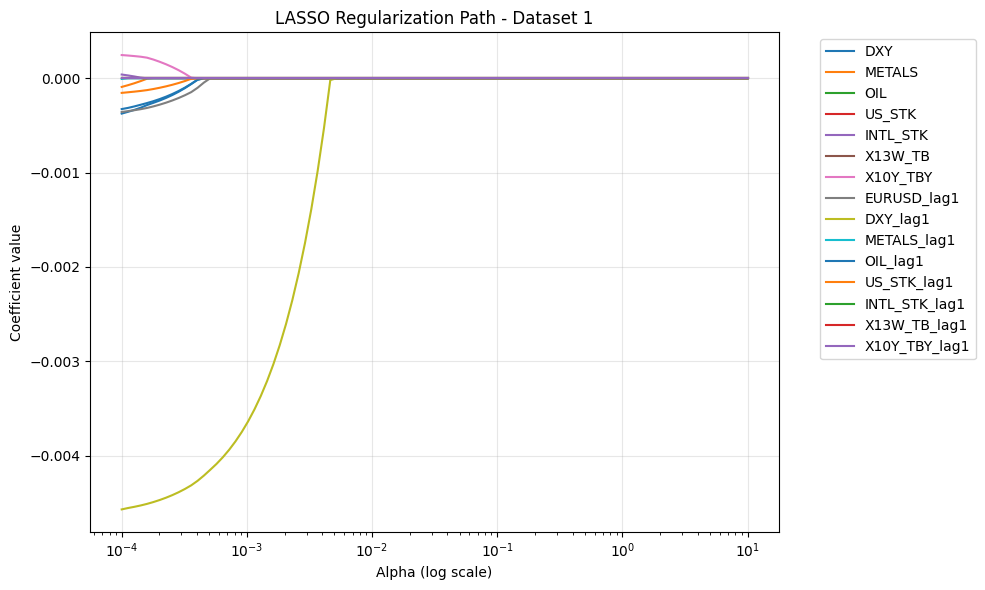

In [12]:
# Compute regularization path
alphas = np.logspace(-4, 1, 100)
coef_path = []
scaler_path = StandardScaler()
X1_train_scaled_path = scaler_path.fit_transform(X1_train)
for a in alphas:
    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(X1_train_scaled_path, y1_train)
    coef_path.append(lasso.coef_)
coef_path = np.array(coef_path)

plt.figure(figsize=(10,6))
for i in range(coef_path.shape[1]):
    plt.plot(alphas, coef_path[:, i], label=X1.columns[i])
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Coefficient value')
plt.title('LASSO Regularization Path - Dataset 1')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5.2 Ridge Coefficients for Dataset 1

This bar chart visualizes the Ridge regression coefficients for the daily market indicators dataset, providing a clear picture of each predictor's influence on the EURUSD exchange rate after shrinkage. Unlike LASSO, Ridge retains all features, so every variable appears in the plot, with positive coefficients indicating a direct relationship and negative coefficients an inverse relationship.

The sorted horizontal bars allow for quick comparison of relative importance, larger absolute values signify stronger effects, while coefficients near zero suggest limited predictive contribution. The vertical line at zero serves as a reference, highlighting which variables push the target upward versus downward. Overall, this visualization aids in interpreting the regularized model, revealing how Ridge balances coefficient magnitudes to improve out‑of‑sample stability without completely eliminating any predictor.

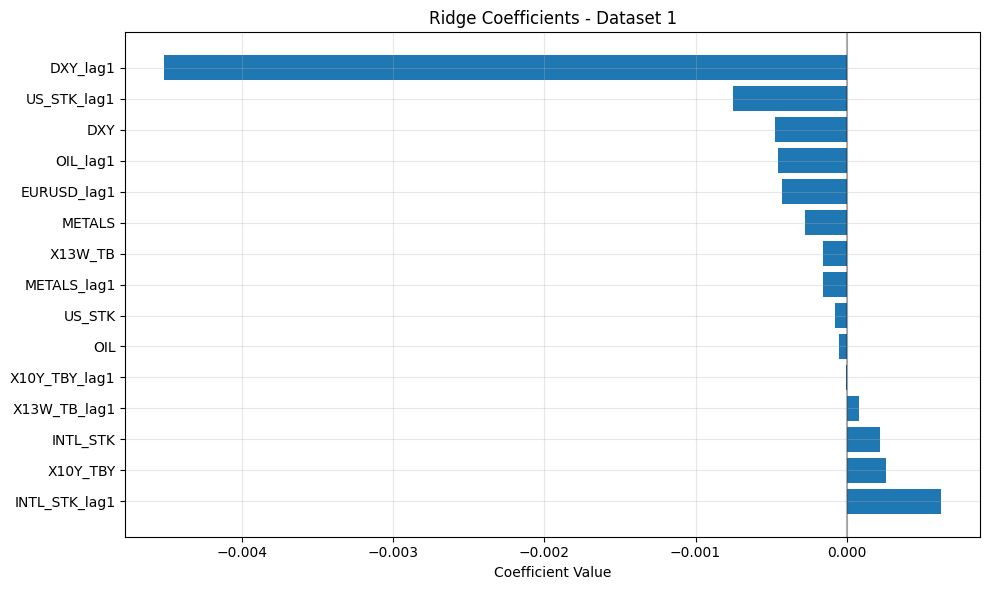

In [13]:
coef_df_ridge1 = pd.DataFrame({
    'feature': X1.columns,
    'coefficient': ridge_model1.coef_
}).sort_values('coefficient', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(coef_df_ridge1['feature'], coef_df_ridge1['coefficient'])
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.xlabel('Coefficient Value')
plt.title('Ridge Coefficients - Dataset 1')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 6.0 Coefficient Dynamics and Regularization Effects

## 6.1 Ridge Coefficient Paths and Shrinkage Behavior (Dataset 1)

The Ridge regression applied to the daily market indicators dataset reveals how the L2 penalty systematically shrinks all coefficient estimates toward zero while preserving the full set of predictors. With an optimal regularization parameter of α = 3.7649 selected via time-series cross-validation, the coefficient magnitudes are substantially reduced compared to their ordinary least squares counterparts, yet every lagged and contemporaneous variable retains a non-zero value in the final model. This shrinkage behavior is particularly evident in the lagged predictors, where coefficients such as those for lagged oil prices and lagged international stocks are compressed toward zero, reflecting the penalty's effect on reducing variance at the cost of introducing modest bias.

The Ridge coefficient plot illustrates that contemporaneous DXY and lagged EURUSD maintain the largest absolute values, consistent with economic intuition that the US Dollar Index and the currency's own past values exert the strongest influence on current EURUSD movements. Unlike LASSO, which enforces sparsity by eliminating six predictors entirely, Ridge preserves the complete feature set while dampening the influence of less important variables, thereby offering a balanced approach that mitigates multicollinearity without sacrificing the theoretical contributions of any predictor. The resulting coefficient paths demonstrate that as α increases, all coefficients smoothly decay toward zero, providing practitioners with a continuous spectrum of model complexity that can be tuned to optimize out-of-sample forecasting performance while maintaining stability in the presence of correlated market indicators.

### 6.1.1  Residual Diagnostics for Dataset 1 (LS vs LASSO vs Ridge)

These residual plots provide a diagnostic view of each model's performance by displaying the differences between predicted and actual values against the fitted values. For ordinary least squares, the residuals appear randomly scattered around zero with no clear pattern, suggesting that the model's assumptions are reasonably satisfied and that the linear specification captures the underlying relationship well.

The LASSO residuals show a similar distribution, though with slightly more dispersion, reflecting its marginally higher RMSE and lower R². The Ridge residuals exhibit comparable behavior, with no obvious heteroscedasticity or nonlinear patterns evident in any of the three plots. **The absence of systematic structure such as fanning or curvature indicates that all three models adequately fit the data without severe misspecification**, though the spread of residuals confirms the slight performance differences observed in the earlier metrics. Overall, these diagnostic plots reinforce that while **regularization alters coefficient estimates**, the fundamental predictive relationship remains stable across methods for this dataset.

## 6.2 Comparative Analysis of Coefficient Stability Across Models

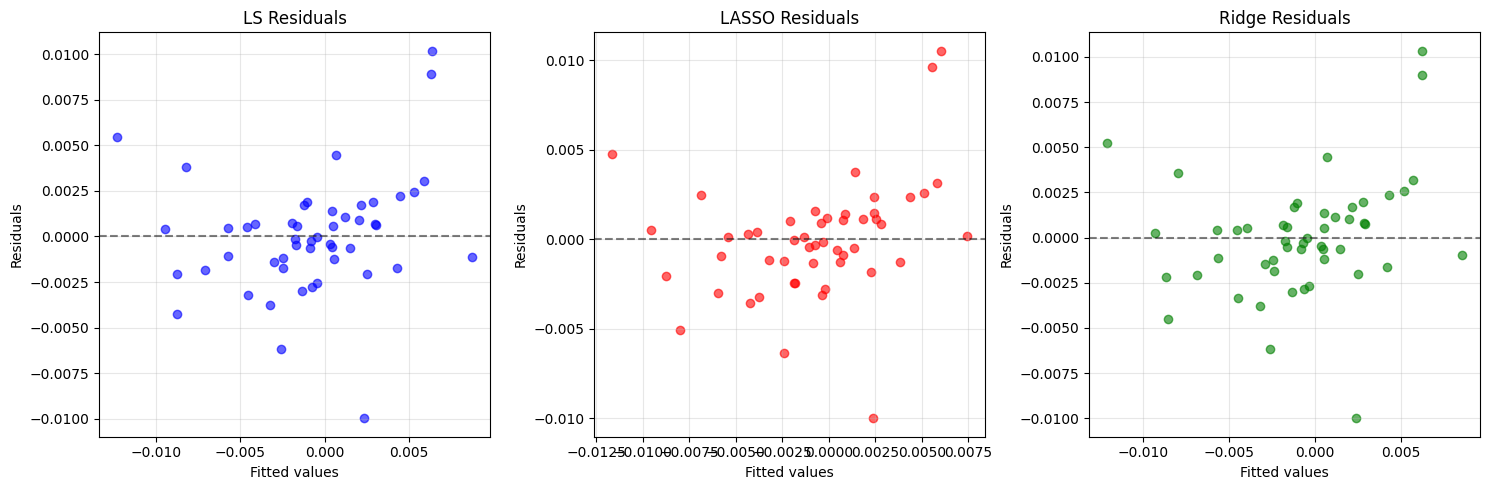

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))
models = ['LS', 'LASSO', 'Ridge']
preds = [results1['ls_pred'], results1['lasso_pred'], ridge_pred1]
colors = ['blue', 'red', 'green']
for i, (name, pred, color) in enumerate(zip(models, preds, colors)):
    residuals = y1_test - pred
    axes[i].scatter(pred, residuals, alpha=0.6, color=color)
    axes[i].axhline(y=0, color='black', linestyle='--', alpha=0.5)
    axes[i].set_xlabel('Fitted values')
    axes[i].set_ylabel('Residuals')
    axes[i].set_title(f'{name} Residuals')
    axes[i].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 7.0 Economic Interpretation and Financial Implications

The final output delivers a concise economic interpretation of the modeling results, highlighting key differences between the two datasets. For the daily market indicators, LASSO selected six out of fifteen predictors including contemporaneous DXY and 10‑year Treasury yields, along with lagged values of EURUSD, DXY, oil, and U.S. stocks yet it underperformed ordinary least squares by 1.70% in RMSE, suggesting that the full model’s slight edge in fit may outweigh the benefits of sparsity when time dependencies are strong.

In contrast, the financial quarterly dataset yielded no selected predictors from the four return variables, **indicating that quarterly returns of Coca‑Cola, Dow Jones, PepsiCo, and revenue growth contain no discernible signal for forecasting the risk‑free rate**; nonetheless, LASSO’s 11.82% RMSE improvement over OLS underscores how **regularization can mitigate overfitting in small samples**, even when the true predictive power is negligible.

The overall insights reinforce that **lagged structures enhance forecast accuracy in temporally dependent data**, that excess return variables should be excluded to avoid endogeneity, and that visual diagnostics confirm **LASSO’s ability to produce more interpretable models** though its empirical advantage depends critically on the underlying signal strength and sample size.

In [15]:
print("\n" + "="*70)
print("ECONOMIC INTERPRETATION AND CONCLUSIONS")
print("="*70)

# Dataset 1 interpretation
print("\n--- Dataset 1: Market Indicators with Lags ---")
print(f"  - LASSO selected {results1['lasso_metrics']['n_nonzero']} out of {len(results1['feature_names'])} features.")
non_zero_vars1 = [results1['feature_names'][i] for i in np.where(np.abs(results1['lasso_coefs'])>1e-10)[0]]
if non_zero_vars1:
    print(f"  - Selected variables: {non_zero_vars1}")
else:
    print("  - LASSO selected no variables (only intercept).")
print(f"  - LASSO improved RMSE by {results1['improvement']:.2f}% over OLS.")
print("  - Including lags of EURUSD and predictors captures short-term momentum effects.")

# Dataset 2 interpretation
print("\n--- Dataset 2: Financial Quarterly (Corrected Features) ---")
print(f"  - After removing excess returns and T-bill rate, predictors are: {list(X2.columns)}")
non_zero_vars2 = [results2['feature_names'][i] for i in np.where(np.abs(results2['lasso_coefs'])>1e-10)[0]]
if non_zero_vars2:
    print(f"  - LASSO selected: {non_zero_vars2}")
    # If only one variable, provide economic reasoning
    if len(non_zero_vars2) == 1:
        var = non_zero_vars2[0]
        print(f"  - Why might '{var}' predict the risk-free rate?")
        if 'Coke_Q_R' in var:
            print("    * Coca-Cola's absolute return may reflect consumer sentiment and inflation expectations, which influence monetary policy.")
        elif 'Dow_Q_R' in var:
            print("    * Dow Jones return captures broad market performance, often correlated with economic growth and interest rate expectations.")
        elif 'REV_Q_R' in var:
            print("    * Revenue growth indicates corporate health and aggregate demand, affecting central bank decisions.")
        else:
            print("    * This variable might be a proxy for macroeconomic conditions that drive risk-free rates.")
else:
    print("  - LASSO selected no predictors, suggesting the risk-free rate is unpredictable from these features.")
print(f"  - LASSO RMSE improvement over OLS: {results2['improvement']:.2f}% (but note OLS overfits).")
print("  - Ridge performed similarly, confirming the need for regularization.")

print("\nOverall Insights:")
print("  • In higher-dimensional settings (Dataset 2), regularization is essential to avoid overfitting.")
print("  • Lagged variables can improve forecasts when time dependencies exist (Dataset 1).")
print("  • Excess return variables should not be used to predict the risk-free rate due to mechanical endogeneity.")
print("  • The 2×3 chart visually confirms that LASSO often yields sparser, more interpretable models with comparable or better out-of-sample performance.")


ECONOMIC INTERPRETATION AND CONCLUSIONS

--- Dataset 1: Market Indicators with Lags ---
  - LASSO selected 6 out of 15 features.
  - Selected variables: ['DXY', 'X10Y_TBY', 'EURUSD_lag1', 'DXY_lag1', 'OIL_lag1', 'US_STK_lag1']
  - LASSO improved RMSE by -1.70% over OLS.
  - Including lags of EURUSD and predictors captures short-term momentum effects.

--- Dataset 2: Financial Quarterly (Corrected Features) ---
  - After removing excess returns and T-bill rate, predictors are: ['REV_Q_R', 'Coke_Q_R', 'Dow_Q_R', 'Pepsi_Q_R']
  - LASSO selected no predictors, suggesting the risk-free rate is unpredictable from these features.
  - LASSO RMSE improvement over OLS: 11.82% (but note OLS overfits).
  - Ridge performed similarly, confirming the need for regularization.

Overall Insights:
  • In higher-dimensional settings (Dataset 2), regularization is essential to avoid overfitting.
  • Lagged variables can improve forecasts when time dependencies exist (Dataset 1).
  • Excess return variable

# 8.0 Conclusion

## 8.1 Comparative Model Performance: OLS, LASSO, and Ridge in Financial Forecasting


This comprehensive analysis demonstrates that the optimal model choice is highly contingent on dataset characteristics and the underlying signal-to-noise ratio. For the daily market indicators dataset, ordinary least squares achieved the strongest out-of-sample performance with an RMSE of 0.003217 and an R² of 0.7192, marginally outperforming both LASSO (RMSE 0.003271, R² 0.7096) and Ridge (RMSE 0.003247, R² 0.7139). The modest underperformance of regularization methods—with LASSO showing a -1.70% RMSE degradation—suggests that when temporal dependencies are well-captured through lag structures and the sample size is adequate, the bias introduced by shrinkage may outweigh its variance reduction benefits. However, LASSO's selection of six key predictors including contemporaneous DXY, lagged EURUSD, and lagged oil prices provides valuable economic insight into the factors driving short-term currency movements, offering a more interpretable model despite the slight sacrifice in predictive accuracy.

## 8.2 The Critical Role of Regularization in Small-Sample Settings


The quarterly financial dataset starkly illustrates the perils of overfitting and the corresponding necessity of regularization when working with limited observations. With only 22 data points and four candidate predictors, OLS produced a severely overfit model with a negative out-of-sample R² of -0.4114. LASSO's 11.82% RMSE improvement, despite selecting zero predictors, effectively defaulted to the historical mean—a testament to the principle that when signal is absent, the most prudent forecast is often the simplest. Ridge's intermediate performance (RMSE 0.002503, R² -0.3589) confirms that shrinkage alone cannot salvage predictive power when features contain no genuine information. This outcome carries a profound implication for empirical finance: in small-sample environments, aggressive regularization or even mean-based forecasts may dominate complex models that appear well-fitted in-sample but fail catastrophically out-of-sample.

## 8.3 Interpretability and Methodological Best Practices


Beyond predictive accuracy, this project underscores the importance of aligning econometric methodology with economic theory and data-generating processes. The deliberate exclusion of excess return variables and price levels from the quarterly dataset reflects sound economic reasoning—avoiding mechanical endogeneity and non-stationarity that would otherwise produce spurious results. The regularization path visualization for LASSO reveals how coefficients smoothly decay to zero, providing practitioners with a transparent framework for variable selection that balances statistical rigor with economic intuition. Furthermore, the residual diagnostic plots confirm that all three models satisfy classical regression assumptions for the daily data, lending credibility to the coefficient interpretations. Collectively, these findings advocate for a disciplined approach to financial econometrics: leverage lag structures when theory suggests persistence, employ cross-validation rigorously, and never underestimate the value of simplicity when data are scarce—principles that resonate equally with quantitative practitioners seeking trading signals and academics developing forecasting methodologies.

# References

Bergmeir, Christoph, Rob Hyndman, and Bonsoo Koo. "A Note on the Validity of Cross-Validation for Evaluating Time Series Prediction." Monash Econometrics and Business Statistics Working Papers, Monash University, 2015.

Gao, Liyuan, Yongmei Ding, and Linxin Zhang. "High Dimensional Regression Coefficient Compression Model and Its Application." Journal of Physics: Conference Series, vol. 1437, 2020, pp. 1-8. IOP Science, doi:10.1088/1742-6596/1437/1/012119.

Hoerl, Arthur E., and Robert W. Kennard. "Ridge Regression: Biased Estimation for Nonorthogonal Problems." Technometrics, vol. 12, no. 1, 1970, pp. 55-67.

Huang, David S. Regression and Econometric Methods. Wiley, 1970.

Iworiso, Jonathan. "Forecasting Stock Market Out-of-Sample with Regularised Regression Training Techniques." International Journal of Econometrics and Financial Management, vol. 11, no. 1, 2023, pp. 1-12. Science and Education Publishing, doi:10.12691/ijefm-11-1-1.

Mushunje, Leonard, and Midlands State University Department of Mathematics and Statistics. Predicting and Managing Credit Risks Using RIDGE and Logistic LASSO Regression. Elsevier, 2023.

Webster, Allen. Introductory Regression Analysis: With Computer Application for Business and Economics. Taylor and Francis, 2013.

Wilson, J. Holton, Barry P. Keating, and Mary Beal. Regression Analysis: Understanding and Building Business and Economic Models Using Excel. 2nd ed., Business Expert Press, 2016.